# RAG-Collapse · HotpotQA diverse-distractor sweep — results

Plots for the `diverse_synth` round-0 distractor experiment (oz03-hub setup): **qwen2.5-14b** answerer +
**qwen2.5-7b-docgen** per-round doc synthesis + **gpt-5-mini** round-0 distractors, native 2-gold/8-distractor
context, gold never corrupted. Sweep over 3 variants × fractions {0, 0.3, 0.5, 0.7}, 3 rounds, 7-question
eligible cohort (10 questions, yes/no dropped), seed 42.

**Data** lives in `oz03_distractor_sweep/` (gitignored). To repopulate:
`scp -r unity:~/oz03_distractor_sweep <repo>/oz03_distractor_sweep`. This notebook reads the
`sweep_summary_<variant>.json` files (per-round aggregates from `compare_sweep.py`).

> Caveat: 7-question cohort — directional, not statistically significant. See `docs/hotpotqa_diverse_synth.html` §11.

In [1]:
import json, pathlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cycler

DATA = pathlib.Path("oz03_distractor_sweep")
VARIANTS = ["search", "hybrid", "replace_one"]
VARIANT_LABEL = {"search": "search (growing store)",
                 "hybrid": "hybrid / replace-all",
                 "replace_one": "replace_one"}
FRACS = ["0", "0.3", "0.5", "0.7"]
ROUNDS = [0, 1, 2]

# palette matching docs/hotpotqa_diverse_synth.html
GROUND, SURFACE, TEXT, DIM, LINE = "#111524", "#1a2034", "#e7e9f2", "#9aa0b8", "#2a3150"
GOLD, VIOLET, TEAL, LEAK = "#e8b23a", "#b45cf0", "#5fd6bf", "#e0696b"
VARIANT_COLOR = {"search": VIOLET, "hybrid": TEAL, "replace_one": GOLD}

plt.rcParams.update({
    "figure.facecolor": GROUND, "axes.facecolor": GROUND, "savefig.facecolor": GROUND,
    "text.color": TEXT, "axes.labelcolor": TEXT, "axes.edgecolor": LINE,
    "xtick.color": DIM, "ytick.color": DIM, "grid.color": LINE,
    "axes.grid": True, "grid.alpha": 0.5, "font.size": 11,
    "axes.titlecolor": TEXT, "legend.frameon": False, "figure.dpi": 110,
})

summ = {}
for v in VARIANTS:
    d = json.loads((DATA / f"sweep_summary_{v}.json").read_text())
    summ[v] = d["fractions"]
COHORT = json.loads((DATA / "sweep_summary_search.json").read_text())["eligible_cohort_size"]

def series(v, frac, metric):
    """metric over rounds for one (variant, fraction)."""
    return [summ[v][frac][str(r)][metric] for r in ROUNDS]

print("loaded", list(summ), "| eligible cohort =", COHORT, "questions")


loaded ['search', 'hybrid', 'replace_one'] | eligible cohort = 7 questions


## 1 · Collapse dynamics across rounds

Each column is a variant; each row a metric. Lines are distractor fractions. This is the core picture:
gold collapses immediately, and the *shape over rounds* differs by variant.

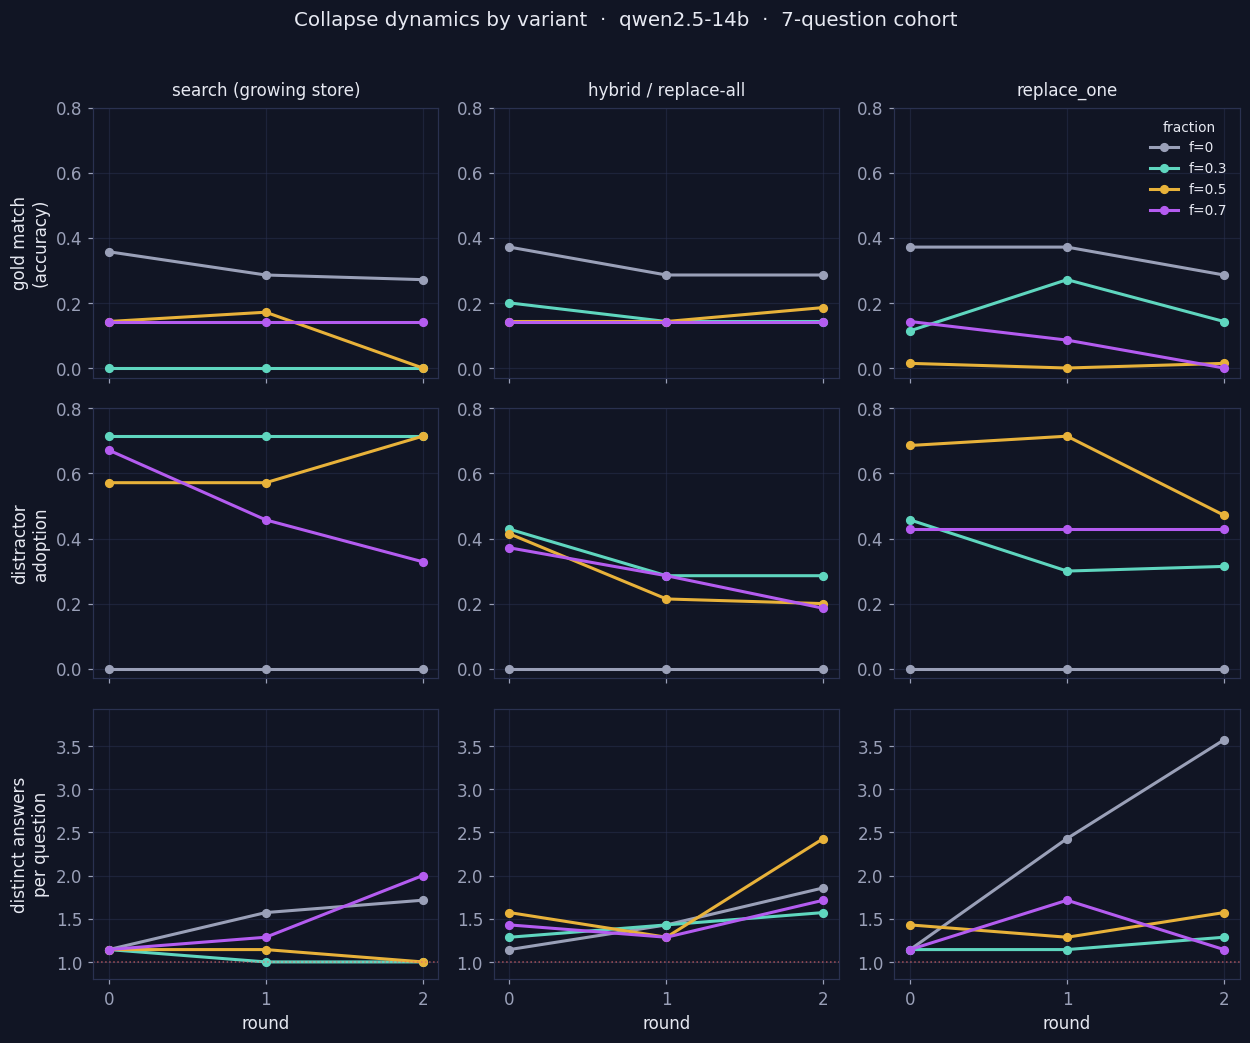

In [2]:
metrics = [("gold_match", "gold match\n(accuracy)"),
           ("distractor_adoption", "distractor\nadoption"),
           ("distinct_answers", "distinct answers\nper question")]
frac_colors = {"0": DIM, "0.3": TEAL, "0.5": GOLD, "0.7": VIOLET}

fig, axes = plt.subplots(3, 3, figsize=(11.5, 9.5), sharex=True)
for r, (m, mlabel) in enumerate(metrics):
    row_max = max(max(series(v, f, m)) for v in VARIANTS for f in FRACS)
    for c, v in enumerate(VARIANTS):
        ax = axes[r][c]
        for f in FRACS:
            ax.plot(ROUNDS, series(v, f, m), marker="o", ms=5, lw=2,
                    color=frac_colors[f], label=f"f={f}")
        ax.set_xticks(ROUNDS)
        if m == "distinct_answers":
            ax.axhline(1.0, color=LEAK, ls=":", lw=1, alpha=0.7)
            ax.set_ylim(0.8, max(3.8, row_max * 1.1))
        else:
            ax.set_ylim(-0.03, max(0.8, row_max * 1.1))
        if r == 0:
            ax.set_title(VARIANT_LABEL[v], color=TEXT, fontsize=11, pad=8)
        if c == 0:
            ax.set_ylabel(mlabel, color=TEXT)
        if r == 2:
            ax.set_xlabel("round")
axes[0][2].legend(title="fraction", loc="upper right", fontsize=9, title_fontsize=9, labelcolor=TEXT)
fig.suptitle("Collapse dynamics by variant  ·  qwen2.5-14b  ·  7-question cohort",
             color=TEXT, fontsize=13, y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


## 2 · Dose-response (final round, r2)

How the *final* state depends on how many of the 8 non-gold slots are distractors. Lines are variants.

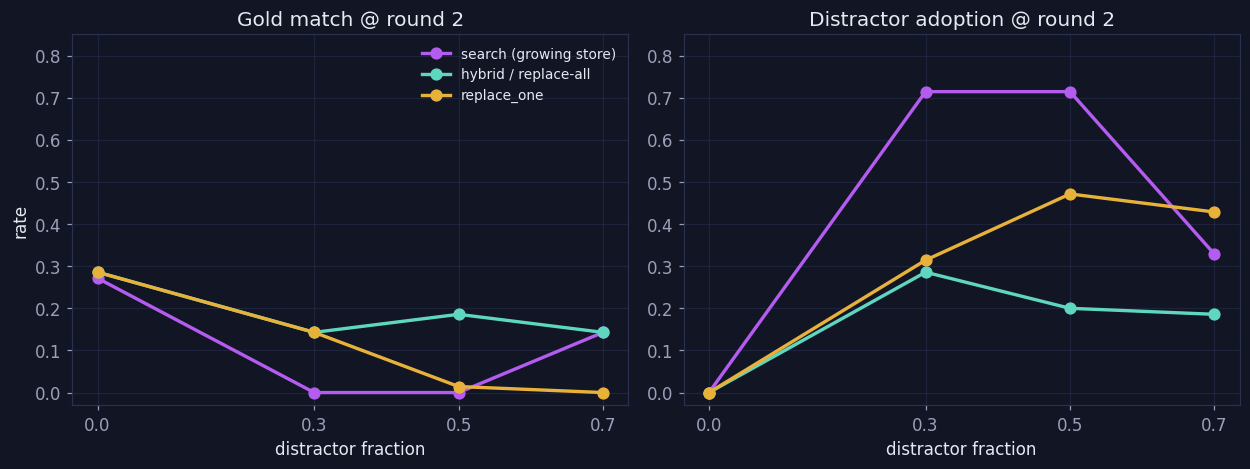

In [3]:
xf = [float(f) for f in FRACS]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
for ax, (m, title) in zip(axes, [("gold_match", "Gold match @ round 2"),
                                  ("distractor_adoption", "Distractor adoption @ round 2")]):
    for v in VARIANTS:
        y = [summ[v][f]["2"][m] for f in FRACS]
        ax.plot(xf, y, marker="o", ms=7, lw=2.2, color=VARIANT_COLOR[v], label=VARIANT_LABEL[v])
    ax.set_title(title, color=TEXT)
    ax.set_xlabel("distractor fraction")
    ax.set_xticks(xf)
    ax.set_ylim(-0.03, 0.85)
axes[0].set_ylabel("rate")
axes[0].legend(fontsize=9, labelcolor=TEXT)
fig.tight_layout()
plt.show()


## 3 · Concentration vs diffusion

`distinct_answers` at the final round. The dotted line at **1.0** is full collapse (every run of a question
gives the *same* answer). `search` drives toward it (lock-in); `replace_one`/`hybrid` rise above it (the loop
spreads answers out) — and the clean `replace_one` baseline (f=0) diverges most.

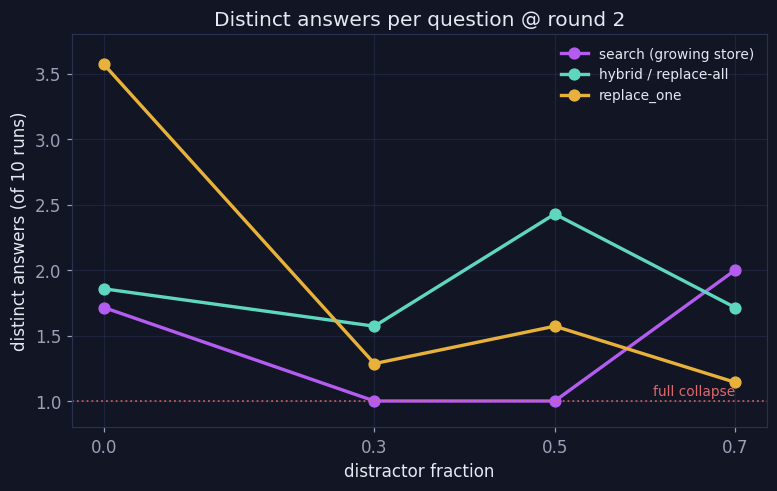

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
for v in VARIANTS:
    y = [summ[v][f]["2"]["distinct_answers"] for f in FRACS]
    ax.plot(xf, y, marker="o", ms=7, lw=2.2, color=VARIANT_COLOR[v], label=VARIANT_LABEL[v])
ax.axhline(1.0, color=LEAK, ls=":", lw=1.2, alpha=0.8)
ax.text(0.70, 1.04, "full collapse", color=LEAK, fontsize=9, ha="right")
ax.set_title("Distinct answers per question @ round 2", color=TEXT)
ax.set_xlabel("distractor fraction"); ax.set_ylabel("distinct answers (of 10 runs)")
ax.set_xticks(xf); ax.set_ylim(0.8, 3.8)
ax.legend(fontsize=9, labelcolor=TEXT)
fig.tight_layout()
plt.show()


## 4 · Example seeded distractors (qualitative)

Straight from a base experiment file: the distinct wrong answers gpt-5-mini planted, and what qwen answered.

In [5]:
bf = json.loads((DATA / "base_search_f0.7.json").read_text())
shown = 0
for q in bf["questions"]:
    dist = q.get("initial_distractor") or {}
    if not dist.get("eligible"):
        continue
    ents = [d["injected_entity"] for d in dist.get("distractors", []) if d.get("injected_entity")]
    it0 = q["iterations"][0]
    answers = [(r.get("answer") or "").strip().replace("\n", " ")[:40] for r in it0["runs"]]
    print("Q:", q["question_text"][:90])
    print("  gold:", dist.get("gold_answer"))
    print("  seeded distractors:", ", ".join(dict.fromkeys(ents)))
    print("  round-0 answers (10 runs):", answers)
    print()
    shown += 1
    if shown >= 3:
        break


Q: What government position was held by the woman who portrayed Corliss Archer in the film Ki
  gold: Chief of Protocol
  seeded distractors: United States Secretary of State, United States Senator, United States Ambassador to the United Nations, United States Attorney General, White House Press Secretary, Governor of California, United States Trade Representative
  round-0 answers (10 runs): ['United States Ambassador to the United N', 'United States Ambassador to the United N', 'United States Ambassador to the United N', 'United States Ambassador to the United N', 'United States Ambassador to the United N', 'United States Ambassador to the United N', 'United States Ambassador to the United N', 'United States Ambassador to the United N', 'United States Ambassador to the United N', 'United States Ambassador to the United N']

Q: What science fantasy young adult series, told in first person, has a set of companion book
  gold: Animorphs
  seeded distractors: The Hunger Games, Divergent,